# Sprint 01 — Couche GOLD (feature engineering : dataset ML)

Transformation `silver → gold` : matrice **features + labels**, une ligne par
`(machine, heure)` **opérationnelle**, pour la **maintenance prédictive**, construite
**sans fuite** depuis le silver.

**Cibles (double, choix au modèle)** : labels binaires `label_incident_{6,12,24,48}h`
(incident dans `(t, t+H]`) **et** `rul_hours` (RUL = heures jusqu'au prochain incident).

**Anti-fuite** : fenêtres glissantes **trailing** 6/12/24/48 h **bornées au segment
inter-maintenance** ; colonnes décrivant l'incident exclues ; scaling/PCA/SMOTE laissés
au modèle (fit train) ; **split chronologique** `train/val/test`.

> **Prérequis** : couche `silver` peuplée (`02_silver`).

## 1. Construction du gold

Équivalent notebook de `uv run indusense-gold` (lit silver, écrit le parquet canonique +
la table `gold.dataset`).

In [1]:
from indusense.data import gold

meta = gold.run()
print(f"lignes : {meta['n_lignes']}  |  features : {meta['n_features']}  |  colonnes : {meta['n_colonnes']}")
print(f"taux positifs par horizon : {meta['taux_positifs']}")
print(f"RUL censurés : {meta['rul_censored']}  |  split : {meta['split']}")

lignes : 130613  |  features : 118  |  colonnes : 127
taux positifs par horizon : {'6h': 0.0433, '12h': 0.0846, '24h': 0.1632, '48h': 0.2509}
RUL censurés : 3258  |  split : {'train': 91389, 'test': 19653, 'val': 19571}


## 2. Figures — équilibre des labels, RUL, corrélations

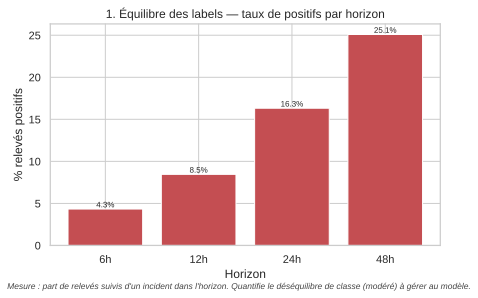

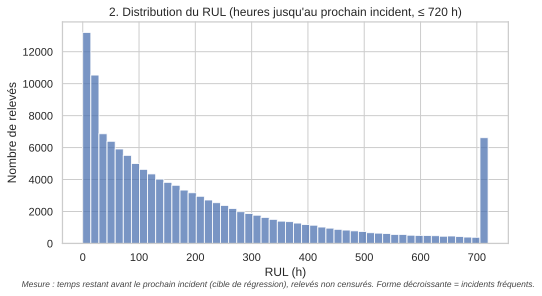

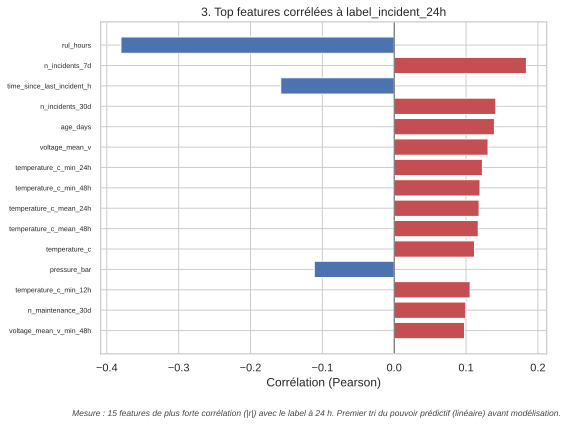

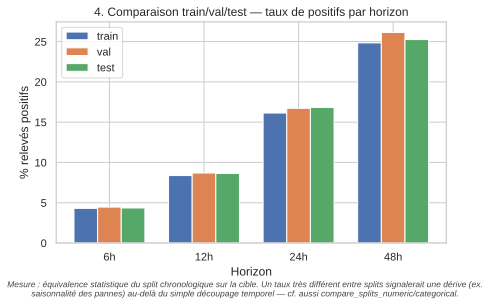

In [2]:
from IPython.display import SVG, display

from indusense import config

run_dir = sorted(p for p in config.GOLD_DIR.glob('2*') if p.is_dir())[-1]
for fig in sorted((run_dir / 'figures').glob('*.svg')):
    display(SVG(filename=str(fig)))

## 3. Aperçu du dataset & contrôles anti-fuite

Forme, split chronologique, absence de colonnes décrivant l'incident, et premières
features corrélées au label à 24 h.

In [3]:
import pandas as pd

gold_df = pd.read_parquet(config.GOLD_DATASET)
print('forme :', gold_df.shape)
print('split :', gold_df['split'].value_counts().to_dict())
fuite = {'severity', 'signal', 'confidence', 'incident_id', 'comment'} & set(gold_df.columns)
print('colonnes de fuite :', fuite or 'aucune')

num = gold_df.select_dtypes('number')
feat = num.drop(columns=[c for c in num if c.startswith('label_incident_') or c == 'rul_censored'])
corr = feat.corrwith(gold_df['label_incident_24h']).dropna().sort_values(key=abs, ascending=False)
print('\nTop 10 features corrélées à label_incident_24h :')
corr.head(10).round(3)

forme : (130613, 127)
split : {'train': 91389, 'test': 19653, 'val': 19571}
colonnes de fuite : aucune



Top 10 features corrélées à label_incident_24h :


rul_hours                    -0.380
n_incidents_7d                0.184
time_since_last_incident_h   -0.158
n_incidents_30d               0.141
age_days                      0.139
voltage_mean_v                0.131
temperature_c_min_24h         0.123
temperature_c_min_48h         0.119
temperature_c_mean_24h        0.118
temperature_c_mean_48h        0.117
dtype: float64

## 4. Équivalence statistique des splits (train/val/test)

Le split est **chronologique** (non aléatoire, cf. section 1) : rien ne garantit *a priori*
que train/val/test restent comparables. Contrôlé à chaque run plutôt que supposé
(`gold.compare_splits_label_rates/numeric/categorical`) : taux de positifs par horizon,
écart standardisé (SMD, Austin 2009 — |SMD| ≥ 0,1 = déséquilibre notable) par feature
numérique, répartition des catégorielles.

In [4]:
label_rates = pd.read_csv(run_dir / "split_label_rates.csv")
numeric_cmp = pd.read_csv(run_dir / "split_numeric_stats.csv")

print(f"{meta['n_features_smd_notable']} feature(s) avec |SMD| >= 0.1 "
      f"(max={meta['smd_max']} sur {meta['smd_max_feature']})")
display(label_rates)
display(numeric_cmp.head(10))

17 feature(s) avec |SMD| >= 0.1 (max=0.3837 sur temperature_c)


,horizon_h,train,val,test
0,6,0.0430,0.0446,0.0435
1,12,0.0837,0.0869,0.0863
2,24,0.1613,0.1672,0.1683
3,48,0.2484,0.2614,0.2525


,feature,train_mean,val_mean,test_mean,smd_train_test
0,temperature_c,48.8293,46.2239,46.8805,-0.3837
1,age_days,1145.6544,1301.0898,1363.4686,0.3689
2,temperature_c_mean_48h,48.4613,46.8975,47.5496,-0.3060
3,temperature_c_mean_24h,48.4862,46.9365,47.5709,-0.2963
4,temperature_c_max_24h,54.8954,53.3716,53.9501,-0.2679
5,temperature_c_max_48h,55.5167,53.9949,54.6145,-0.2669
6,temperature_c_min_48h,41.5157,39.8921,40.5793,-0.2463
7,temperature_c_min_24h,42.1353,40.5542,41.2344,-0.2433
8,temperature_c_max_12h,53.2920,51.7668,52.3474,-0.2348
9,temperature_c_mean_12h,48.4996,46.9601,47.5785,-0.2314


*Lecture des 2 premières lignes* : `age_days` dérive mécaniquement (le split étant
chronologique, les machines sont — logiquement — plus âgées sur le test que sur le train) ;
`temperature_c` et ses agrégats glissants dérivent en revanche pour une raison à creuser
(vraisemblablement saisonnière), cf. Conclusions.

➡️ **Conclusions**

- **Gold prêt pour le modèle** : ~130 k lignes opérationnelles, ~118 features brutes,
  cibles binaires (6/12/24/48 h) + RUL.
- **Déséquilibre modéré** : ~16 % de positifs à 24 h, ~25 % à 48 h (SMOTE optionnel).
- **Anti-fuite garanti** : features trailing bornées au segment, split chronologique
  disjoint, aucune colonne décrivant l'incident.
- **Reporté au modèle** (phase suivante) : TimeSeriesSplit, scaling/PCA/SMOTE *fit sur
  train*, baseline + métriques.
- **Split vérifié, pas juste supposé** : cible et composition du parc stables entre
  train/val/test (contrôle SMD) ; seul point de vigilance réel — la température (capteur +
  agrégats glissants) dérive entre train et test (SMD jusqu'à -0,38), probablement
  saisonnière. À surveiller en B7 si le modèle s'appuie sur des seuils absolus plutôt que des
  variations relatives.